# Projeto Olist: Análise Exploratória com SQL e Pandas

Este notebook faz parte de um estudo de caso focado em **Engenharia e Análise de Dados**. O objetivo é extrair insights de negócio a partir de um banco de dados relacional (SQLite) utilizando a biblioteca Pandas para manipulação e cálculos estatísticos.

## 1. Configuração do Ambiente e Conexão
Nesta etapa inicial, importamos as bibliotecas necessárias e estabelecemos a conexão com o banco de dados `olist.db`, gerado previamente via script de automação.

In [63]:
import pandas as pd

In [64]:
import sqlite3

# Conectar ao banco (lembre-se: como o notebook está na pasta 'notebooks', 
# precisamos usar '../' para voltar uma pasta e achar a 'data')
conn = sqlite3.connect(r'C:\Users\nayar\projetos_portfolio\estudos-engenharia-dados\05-analise-pandas-sql\data\olist.db')

# Ler os primeiros 5 clientes para testar
df = pd.read_sql_query("SELECT * FROM customers LIMIT 5", conn)
df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## 3. Distribuição Geográfica de Clientes
Utilizamos funções de agregação em SQL (`COUNT` e `GROUP BY`) para identificar os principais polos de consumo da plataforma. Esta análise ajuda a entender a concentração de mercado por cidade.

In [65]:
query = """
SELECT 
    customer_city, 
    COUNT(customer_id) as total_clientes
FROM customers
GROUP BY customer_city
ORDER BY total_clientes DESC
LIMIT 5
"""

df_top_cidades = pd.read_sql_query(query, conn)
df_top_cidades

,customer_city,total_clientes
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521


Observamos que a cidade de São Paulo representa o maior volume de clientes, indicando uma alta concentração logística e de mercado na região Sudeste.

## 4. Desempenho Financeiro por Categoria
Para responder perguntas de negócio sobre receita, realizamos um **JOIN** entre as tabelas de itens de pedido e produtos. O objetivo é ranquear as categorias que mais contribuem para o faturamento total da Olist.

In [66]:
query = """
SELECT 
    t2.product_category_name,
    SUM(t1.price) as faturamento_total
FROM order_items as t1
LEFT JOIN products as t2
    ON t1.product_id = t2.product_id
GROUP BY t2.product_category_name
ORDER BY faturamento_total DESC
LIMIT 10
"""

df_faturamento = pd.read_sql_query(query, conn)
df_faturamento

,product_category_name,faturamento_total
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


## 5. Faturamento por Localização do Vendedor
Nesta análise, tratamos os Estados de origem dos vendedores como "filiais" para entender a distribuição geográfica da receita. Utilizamos um `JOIN` entre as tabelas de itens e vendedores para consolidar os valores financeiros por unidade federativa.

In [67]:
query_filiais = """
SELECT 
    t2.seller_state as estado_vendedor,
    SUM(t1.price) as faturamento_total
FROM order_items as t1
JOIN sellers as t2 ON t1.seller_id = t2.seller_id
GROUP BY t2.seller_state
ORDER BY faturamento_total DESC
"""
df_filiais = pd.read_sql_query(query_filiais, conn)
df_filiais

,estado_vendedor,faturamento_total
0,SP,8753396.21
1,PR,1261887.21
2,MG,1011564.74
3,RJ,843984.22
4,SC,632426.07
5,RS,378559.54
6,BA,285561.56
7,DF,97749.48
8,PE,91493.85
9,GO,66399.21


## 6. Participação de Mercado (Share) por Categoria
Para identificar a relevância de cada departamento no faturamento global, calculamos o percentual de participação (Share). Aqui, combinamos o poder de agregação do **SQL** para a extração dos dados com a flexibilidade do **Pandas** para o cálculo das métricas de proporção.

In [68]:
# Primeiro pegamos o faturamento por categoria
query_cat = """
SELECT 
    t2.product_category_name,
    SUM(t1.price) as faturamento
FROM order_items as t1
JOIN products as t2 ON t1.product_id = t2.product_id
GROUP BY t2.product_category_name
"""
df_participacao = pd.read_sql_query(query_cat, conn)

# Calculando o percentual no Pandas
total_geral = df_participacao['faturamento'].sum()
df_participacao['percentual'] = (df_participacao['faturamento'] / total_geral) * 100

df_participacao.sort_values('percentual', ascending=False).head(10)

,product_category_name,faturamento,percentual
12,beleza_saude,1258681.34,9.260700
67,relogios_presentes,1205005.68,8.865783
14,cama_mesa_banho,1036988.68,7.629605
33,esporte_lazer,988048.97,7.269533
45,informatica_acessorios,911954.32,6.709669
55,moveis_decoracao,729762.49,5.369200
27,cool_stuff,635290.85,4.674128
73,utilidades_domesticas,632248.66,4.651745
9,automotivo,592720.11,4.360916
41,ferramentas_jardim,485256.46,3.570256


## 7. Análise Cruzada: Categoria vs. Região (Pivot Table)
Para entender o comportamento de consumo regional, criamos uma Tabela Dinâmica (*Pivot Table*) cruzando as categorias de produtos com os estados dos clientes. Essa técnica permite visualizar padrões de preferência geográfica de forma multidimensional.

In [69]:
# Query para trazer os dados necessários
query_pivot = """
SELECT 
    t3.customer_state,
    t2.product_category_name,
    t1.price
FROM order_items as t1
JOIN products as t2 ON t1.product_id = t2.product_id
JOIN orders as o ON t1.order_id = o.order_id
JOIN customers as t3 ON o.customer_id = t3.customer_id
WHERE t3.customer_state IN ('SP', 'RJ', 'MG', 'RS', 'PR') -- Filtrando os 5 maiores estados
"""

df_raw = pd.read_sql_query(query_pivot, conn)

# Criando a Pivot Table no Pandas
pivot_result = df_raw.pivot_table(
    index='product_category_name', 
    columns='customer_state', 
    values='price', 
    aggfunc='sum'
).fillna(0)

# Mostrando as top 10 categorias
pivot_result.sort_values('SP', ascending=False).head(10)

customer_state,MG,PR,RJ,RS,SP
product_category_name,,,,,
cama_mesa_banho,129643.98,45598.47,148035.23,60270.74,478284.52
beleza_saude,157558.30,54949.36,145298.62,51327.72,462305.22
relogios_presentes,123759.23,59967.04,185379.65,48152.53,435009.92
esporte_lazer,112719.19,58630.20,125148.04,53788.32,386357.01
informatica_acessorios,111069.74,44127.09,120289.45,52757.73,350747.88
moveis_decoracao,78999.74,49484.89,98427.86,54813.58,286708.02
utilidades_domesticas,78073.72,31221.60,77675.57,38994.63,275378.63
automotivo,72851.08,28134.02,65838.10,26333.12,214277.27
cool_stuff,72778.48,37539.12,83909.95,46676.34,213186.89


## 7. Técnicas de Seleção e Fatiamento
Exploramos o uso do método `.iloc`, que permite a seleção de dados baseada em sua posição (índices). Esta técnica é útil para extrair fatias específicas do DataFrame (*slicing*), independentemente dos rótulos das colunas.

In [70]:
# Pegando as 10 primeiras linhas e as 3 primeiras colunas
df_participacao.iloc[:10, 0:3]

,product_category_name,faturamento,percentual
0,NaN,179535.28,1.320924
1,agro_industria_e_comercio,72530.47,0.533640
2,alimentos,29393.41,0.216261
3,alimentos_bebidas,15179.48,0.111682
4,artes,24202.64,0.178070
5,artes_e_artesanato,1814.01,0.013347
6,artigos_de_festas,4485.18,0.033000
7,artigos_de_natal,8800.82,0.064752
8,audio,50688.50,0.372939
9,automotivo,592720.11,4.360916


## 8. Filtros Condicionais
Nesta etapa, aplicamos filtros lógicos para isolar registros que atendem a critérios específicos de negócio. Utilizamos operadores booleanos (`&` para 'e', `|` para 'ou') para construir consultas complexas diretamente no DataFrame, simulando a cláusula `WHERE` do SQL, porém com a performance em memória do Pandas.

In [71]:
# Criando um filtro condicional complexo
filtro_elite = (df_participacao['faturamento'] > 100000) & (df_participacao['percentual'] > 5)

# Aplicando o filtro
categorias_premium = df_participacao[filtro_elite]
categorias_premium

,product_category_name,faturamento,percentual
12,beleza_saude,1258681.34,9.260700
14,cama_mesa_banho,1036988.68,7.629605
33,esporte_lazer,988048.97,7.269533
45,informatica_acessorios,911954.32,6.709669
55,moveis_decoracao,729762.49,5.369200
67,relogios_presentes,1205005.68,8.865783


No Pandas, o Índice não é apenas um contador de linhas; ele é o "endereço" do dado

.iloc: Você usa números (posições). É como dizer: "Vá na gaveta 1 e pegue os itens de 0 a 5".

.loc ou Filtro Direto: Você usa rótulos ou condições. É como dizer: "Pegue todos os itens que custam mais de 10 reais".

## 9. Operações com Índices
A manipulação de índices é essencial para a organização e performance das consultas no Pandas. Nesta seção, exploramos como definir uma coluna como identificador principal (`set_index`), como retornar ao estado original (`reset_index`) e como renomear ou acessar metadados do DataFrame através de `.index` e `.columns`.

Útil para preparar dados para Gráficos (o Matplotlib e o Seaborn usam o índice para rotular os eixos).

In [72]:
# Definindo a categoria como índice
df_cat_index = df_participacao.set_index('product_category_name')

# Ver os dados apenas de 'perfumaria'
print(df_cat_index.loc['perfumaria'])



faturamento    399124.870000
percentual          2.936546
Name: perfumaria, dtype: float64


In [73]:
# Resetando o índice (útil quando você quer transformar o índice de volta em coluna)
df_original = df_cat_index.reset_index()

# Acessando os nomes das colunas e o tipo do índice
print(df_participacao.columns)
print(df_participacao.index)


Index(['product_category_name', 'faturamento', 'percentual'], dtype='str')
RangeIndex(start=0, stop=74, step=1)


## 10. Índices Multiníveis (MultiIndex)
A criação de índices hierárquicos permite trabalhar com dimensões superiores em uma estrutura bidimensional (DataFrame). Esta técnica é fundamental para organizar dados que possuem uma subordinação natural, como divisões geográficas (Estado > Cidade) ou temporais (Ano > Mês). Utilizamos o método `pd.MultiIndex.from_tuples()` para estruturar essa hierarquia, facilitando agregações complexas e seleções multidimensionais.

No dia a dia, muitas vezes o MultiIndex surge "sozinho" quando fazemos um groupby com duas colunas.

Para consolidar o aprendizado de índices multiníveis, realizamos uma análise de faturamento cruzando a localização do cliente (`customer_state`) com a categoria do produto (`product_category_name`). Ao agrupar os dados por múltiplas colunas, o Pandas gera automaticamente um **MultiIndex**, permitindo uma navegação hierárquica pelos resultados de venda da Olist.

In [74]:
# Query para buscar Estado, Categoria e Preço
query_multi = """
SELECT 
    t3.customer_state,
    t2.product_category_name,
    t1.price
FROM order_items as t1
JOIN products as t2 ON t1.product_id = t2.product_id
JOIN orders as o ON t1.order_id = o.order_id
JOIN customers as t3 ON o.customer_id = t3.customer_id
"""

df_vendas_geo = pd.read_sql_query(query_multi, conn)

# Criando o agrupamento que gera o MultiIndex automaticamente.  Agrupamos por Estado e Categoria, somando o Preço
analise_multi = df_vendas_geo.groupby(['customer_state', 'product_category_name']).sum()

analise_multi

price
customer_state product_category_name               
AC             artigos_de_natal               69.90
               automotivo                    540.98
               bebes                         697.84
               beleza_saude                 1386.58
               brinquedos                    234.79
...                                             ...
TO             portateis_casa_forno_e_cafe  1999.00
               relogios_presentes           5446.89
               telefonia                    1268.12
               telefonia_fixa               1390.99
               utilidades_domesticas        1275.75

[1368 rows x 1 columns]

In [75]:
# método Cross-section: use o .xs para responder perguntas como: "Como a categoria X performa em diferentes regiões?"
analise_multi.xs('perfumaria', level='product_category_name')

,price
customer_state,
AC,303.88
AL,1766.66
AM,94.89
BA,9723.01
CE,8747.73
DF,9948.04
ES,6577.55
GO,10291.58
MA,4436.58


## 11. Tratamento de Dados Ausentes (Missing Data)
A presença de valores nulos (`NaN`) é comum em datasets reais e pode comprometer análises estatísticas. Exploramos estratégias de limpeza e imputação, como a remoção seletiva (`dropna`), o preenchimento com valores constantes ou estatísticos (`fillna`) e métodos de propagação temporal (`ffill` e `bfill`). A escolha da estratégia depende do impacto do dado ausente no contexto de negócio.

In [76]:
# Identificando onde estão os nulos
query_produtos = "SELECT * FROM products"
df_produtos = pd.read_sql_query(query_produtos, conn)

# Para uma tomada de decisão assertiva sobre a estratégia de limpeza, calculamos a representatividade dos 
# valores ausentes em cada coluna. Esta métrica é vital para identificar se a perda de dados é estatisticamente
# significativa em relação ao volume total do dataset de produtos.

print("Valores nulos por coluna:")

# Calculando a soma de nulos e o total de registros
nulos_contagem = df_produtos.isnull().sum()
total_registros = len(df_produtos)

# Criando um novo DataFrame para consolidar as informações
df_diagnostico = pd.DataFrame({
    'Total_Nulos': nulos_contagem,
    'Percentual_%': (nulos_contagem / total_registros) * 100
})

# Filtrando apenas onde há nulos e ordenando
df_diagnostico = df_diagnostico[df_diagnostico['Total_Nulos'] > 0].sort_values('Percentual_%', ascending=False)

df_diagnostico



Valores nulos por coluna:


,Total_Nulos,Percentual_%
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


A ausência de categorias em menos de 2% da base permite o preenchimento por um valor genérico ('Outros') sem distorcer o comportamento das categorias principais.

In [77]:
# Exemplo de fillna: Preenchendo categorias vazias com 'nao_informado'
df_produtos['product_category_name'] = df_produtos['product_category_name'].fillna('nao_informado')
df_produtos['product_category_name'].isna().sum()



np.int64(0)

### 11.1. Refinando a Limpeza: Imputação em vez de Exclusão
Após uma análise crítica, optamos por não excluir registros com valores nulos nas características físicas dos produtos (fotos, peso e dimensões). A exclusão poderia causar inconsistências em análises de faturamento futuro. Em vez disso, aplicamos a **imputação de dados**:
- **Fotos:** Valores ausentes preenchidos com `0`.
- **Dimensões e Peso:** Preenchidos com a **mediana**, garantindo que o produto ainda exista para cálculos de receita, mesmo com dados técnicos incompletos.

Excluir é sempre a última opção, deve-se manter a integridade referencial.

In [78]:
# Tratando a quantidade de fotos (preenchendo com 0)
df_produtos['product_photos_qty'] = df_produtos['product_photos_qty'].fillna(0)

# Tratando peso e dimensões com a MEDIANA
# Usamos a mediana porque se houver um produto extremamente pesado (outlier), 
# ele não puxa o valor para cima como a média faria.
df_produtos['product_weight_g'] = df_produtos['product_weight_g'].fillna(df_produtos['product_weight_g'].median())
df_produtos['product_length_cm'] = df_produtos['product_length_cm'].fillna(df_produtos['product_length_cm'].median())
df_produtos['product_height_cm'] = df_produtos['product_height_cm'].fillna(df_produtos['product_height_cm'].median())
df_produtos['product_width_cm'] = df_produtos['product_width_cm'].fillna(df_produtos['product_width_cm'].median())

# Verificando se ainda restam nulos (exceto na categoria, que já tratamos como 'nao_informado')
print("Nulos restantes:")
print(df_produtos.isnull().sum())

Nulos restantes:
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty              0
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64


### 11.2. Refinamento de Atributos (Feature Selection)
Durante o processo de limpeza, identificamos colunas técnicas (`product_name_lenght` e `product_description_lenght`) que armazenam apenas a contagem de caracteres de campos textuais. Como o escopo atual do projeto foca em performance comercial e logística, essas variáveis não agregam valor analítico e foram removidas para otimizar o uso de memória e a clareza do dataset.

In [79]:
# Removendo as colunas de comprimento de texto que não serão utilizadas
colunas_para_remover = ['product_name_lenght', 'product_description_lenght']
df_produtos = df_produtos.drop(columns=colunas_para_remover)

# Verificando o resultado final
print("Colunas restantes no df_produtos:")
print(df_produtos.columns.tolist())
print(f"\nNulos totais agora: {df_produtos.isnull().sum().sum()}")

Colunas restantes no df_produtos:
['product_id', 'product_category_name', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Nulos totais agora: 0


## 12. Agrupamentos e Métricas Multidimensionais
Para além da soma básica, utilizamos o método `.agg()` para aplicar múltiplas funções de agregação simultaneamente. Esta técnica permite obter uma visão holística de cada categoria, analisando não apenas o faturamento total, mas também o ticket médio, a variabilidade dos preços (desvio padrão) e o volume de transações em uma única operação.

In [80]:
# Criando um DataFrame com faturamento e informações de produto
query_agg = """
SELECT 
    t2.product_category_name,
    t1.price
FROM order_items as t1
JOIN products as t2 ON t1.product_id = t2.product_id
"""
df_vendas = pd.read_sql_query(query_agg, conn)

# Usando o .agg para aplicar vários métodos de uma vez
analise_estatistica = df_vendas.groupby('product_category_name')['price'].agg([
    'sum',          # Faturamento Total
    'mean',         # Ticket Médio (Média)
    'median',       # Mediana (útil para ver se há preços muito fora do padrão)
    'count',        # Quantidade de itens vendidos
    'std',          # Desvio Padrão (mostra a variação de preços na categoria)
    'max'           # Preço do produto mais caro da categoria
])

# Renomeando as colunas 
analise_estatistica.columns = [
    'Faturamento_Total', 'Ticket_Medio', 'Mediana_Preco', 
    'Qtd_Vendida', 'Variacao_Preco', 'Preco_Maximo'
]

analise_estatistica.sort_values('Faturamento_Total', ascending=False).head(10)

,Faturamento_Total,Ticket_Medio,Mediana_Preco,Qtd_Vendida,Variacao_Preco,Preco_Maximo
product_category_name,,,,,,
beleza_saude,1258681.34,130.163531,79.90,9670,179.499147,3124.00
relogios_presentes,1205005.68,201.135984,129.00,5991,256.742470,3999.90
cama_mesa_banho,1036988.68,93.296327,79.05,11115,82.128028,1999.98
esporte_lazer,988048.97,114.344285,78.00,8641,162.471635,4059.00
informatica_acessorios,911954.32,116.513903,81.99,7827,169.974919,3699.99
moveis_decoracao,729762.49,87.564494,65.49,8334,88.832037,1899.00
cool_stuff,635290.85,167.357969,129.99,3796,200.090161,3109.99
utilidades_domesticas,632248.66,90.788148,59.80,6964,141.533996,6735.00
automotivo,592720.11,139.957523,84.90,4235,211.465655,2258.00


mean vs median: Se a média for muito maior que a mediana, vimos que existem alguns produtos "caríssimos" (outliers) que estão puxando a média para cima.

std (Desvio Padrão): Se o desvio padrão for alto, a categoria é diversificada (vende desde baratinhos até luxo). Se for baixo, os preços são todos muito parecidos.

count: Ajuda a separar categorias que faturam muito porque vendem caro (ex: Relógios) de categorias que faturam muito porque vendem muito (ex: Beleza e Saúde).

In [81]:
# Aplicando o describe no faturamento por categoria
resumo_categorias = df_vendas.groupby('product_category_name')['price'].describe()

# Ordenando pelas categorias que possuem a maior média de preço
resumo_categorias.sort_values('mean', ascending=False).head(10)

,count,mean,std,min,25%,50%,75%,max
product_category_name,,,,,,,,
pcs,203.0,1098.340542,668.513798,34.50,650.000,1100.000,1340.000,6729.00
portateis_casa_forno_e_cafe,76.0,624.285658,609.848752,10.19,96.000,587.000,795.000,2899.00
eletrodomesticos_2,238.0,476.124958,544.416488,13.90,159.000,225.945,559.675,2350.00
agro_industria_e_comercio,212.0,342.124858,419.429802,12.99,35.000,258.650,426.000,2990.00
instrumentos_musicais,680.0,281.616000,446.041029,4.90,55.000,94.835,299.900,4399.87
eletroportateis,679.0,280.778468,471.259273,6.50,49.500,99.000,299.000,4799.00
portateis_cozinha_e_preparadores_de_alimentos,15.0,264.568667,411.063584,17.42,20.805,34.900,310.350,1099.00
telefonia_fixa,264.0,225.693182,420.831784,6.00,30.650,64.485,158.000,1790.00
construcao_ferramentas_seguranca,194.0,208.992371,318.683621,8.90,66.000,125.575,229.045,3099.90


## 13. Integração de Dados: Consolidando o Modelo Relacional
Nesta etapa, realizamos a integração das diferentes entidades do banco de dados (Pedidos, Pagamentos, Clientes e Itens). Através do método `.merge()`, aplicamos a lógica de *Joins* para unificar informações dispersas, permitindo uma visão de 360 graus do ciclo de vida da transação. 

As estratégias utilizadas focam em:
- **Inner Joins**: Para análises onde a correspondência exata entre chaves é obrigatória.
- **Left Joins**: Para garantir a manutenção dos registros da tabela principal (ex: Pedidos), mesmo quando informações complementares (ex: Pagamentos) ainda não estão presentes.
- **Saneamento de Chaves**: Verificação de integridade referencial para evitar a duplicação de registros durante a consolidação.

In [82]:
# 1. Carregando as tabelas
df_pedidos = pd.read_sql("SELECT order_id, customer_id FROM orders", conn)
df_pagamentos = pd.read_sql("SELECT order_id, payment_type, payment_value FROM order_payments", conn)

# 2. Fazendo o MERGE (Unindo pela coluna 'order_id')
# União de todos os pedidos, mesmo que o pagamento ainda não tenha sido processado (Left Join)
df_consolidado = pd.merge(df_pedidos, df_pagamentos, on='order_id', how='left')

df_consolidado.head()

,order_id,customer_id,payment_type,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,credit_card,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,voucher,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,boleto,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,credit_card,179.12


### 13.1. Análise de Eficiência: Vendedores por Estado
Nesta seção, realizamos o cruzamento entre a tabela de itens vendidos (`order_items`) e o cadastro de vendedores (`sellers`). O objetivo é identificar a performance comercial de cada região, calculando o faturamento total e a média de valor por transação. Utilizamos o método `merge` com a estratégia *Inner Join* para garantir que apenas itens com vendedores devidamente identificados sejam contabilizados.

In [83]:
# 1. Carregando os dados do banco
query_vendedores = "SELECT seller_id, seller_state FROM sellers"
query_itens = "SELECT seller_id, price FROM order_items"

df_sellers = pd.read_sql_query(query_vendedores, conn)
df_items = pd.read_sql_query(query_itens, conn)

# 2. Realizando o MERGE
# Unimos pela coluna 'seller_id' que é a chave comum
df_vendas_vendedores = pd.merge(df_items, df_sellers, on='seller_id', how='inner')

# 3. Agrupando por Estado para calcular a eficiência
eficiencia_vendedores = df_vendas_vendedores.groupby('seller_state')['price'].agg([
    'sum',      # Faturamento Total
    'count',    # Volume de Vendas
    'mean'      # Ticket Médio (Eficiência por venda)
]).sort_values('sum', ascending=False)

eficiencia_vendedores.columns = ['Faturamento_Total', 'Volume_Vendas', 'Ticket_Medio']

eficiencia_vendedores.head(10)

,Faturamento_Total,Volume_Vendas,Ticket_Medio
seller_state,,,
SP,8753396.21,80342,108.951684
PR,1261887.21,8671,145.529606
MG,1011564.74,8827,114.598928
RJ,843984.22,4818,175.173147
SC,632426.07,4075,155.196582
RS,378559.54,2199,172.150769
BA,285561.56,643,444.108180
DF,97749.48,899,108.731346
PE,91493.85,448,204.227344


### 💡 Insight: Volume vs. Valor Agregado
Ao analisar a eficiência dos estados, observa-se um fenômeno interessante:
* **Liderança em Volume:** São Paulo (SP) detém o maior faturamento absoluto, impulsionado por um volume de vendas massivo (mais de 80 mil itens), porém com um dos menores Tickets Médios da lista (~R$ 108). Isso sugere uma predominância de produtos de giro rápido e baixo custo.
* **A Surpresa da Eficiência:** O estado da **Bahia (BA)**, apesar de estar em 7º lugar em faturamento total, apresenta o **maior Ticket Médio disparado (~R$ 444)**. 

**Conclusão:** Enquanto os vendedores de SP focam em escala, os vendedores da Bahia parecem operar em um nicho de produtos de maior valor agregado (como eletrônicos ou itens especializados), faturando proporcionalmente muito mais por cada venda realizada.


SP é o motor logístico (baixo preço, muita saída).

BA é o ponto de eficiência (pouca saída, alto lucro por item).

RJ e RS também mostram tickets médios saudáveis (acima de R$ 170), indicando um equilíbrio melhor entre volume e valor do que o Paraná (PR) ou Minas Gerais (MG).

### 13.2. Concatenação: Benchmarking Regional
Para exercitar o método `pd.concat()`, simulamos uma análise segmentada. Isolamos os dados de performance de São Paulo (líder em volume) e da região Nordeste (destaque em ticket médio). Após o processamento individual, utilizamos a concatenação para reunir esses diferentes recortes em um único DataFrame de comparação estratégica, demonstrando como consolidar dados de fontes ou filtros distintos.

In [84]:
# 1. Lista de estados do Nordeste que queremos analisar
estados_ne_alvos = ['BA', 'PE', 'CE', 'RN', 'AL', 'PB', 'SE', 'MA', 'PI']
print(estados_ne_alvos)
# Filtrando apenas os que existem de fato no seu índice para evitar o KeyError
estados_presentes = eficiencia_vendedores.index.intersection(estados_ne_alvos)
print(estados_presentes)

# Agora o .loc não vai reclamar, pois só pediremos o que existe
df_sp = eficiencia_vendedores.loc[['SP']]
df_nordeste = eficiencia_vendedores.loc[estados_presentes]

# 2. Aplicando o CONCAT
comparativo_regional = pd.concat([df_sp, df_nordeste])

# 3. Criando a coluna de Região dinamicamente
comparativo_regional['Regiao'] = ['Sudeste (SP)'] + (['Nordeste'] * len(df_nordeste))

comparativo_regional

['BA', 'PE', 'CE', 'RN', 'AL', 'PB', 'SE', 'MA', 'PI']
Index(['BA', 'PE', 'MA', 'CE', 'PB', 'RN', 'PI', 'SE'], dtype='str', name='seller_state')


,Faturamento_Total,Volume_Vendas,Ticket_Medio,Regiao
seller_state,,,,
SP,8753396.21,80342,108.951684,Sudeste (SP)
BA,285561.56,643,444.108180,Nordeste
PE,91493.85,448,204.227344,Nordeste
MA,36408.95,405,89.898642,Nordeste
CE,20240.64,94,215.325957,Nordeste
PB,17095.00,38,449.868421,Nordeste
RN,9992.60,56,178.439286,Nordeste
PI,2522.00,12,210.166667,Nordeste
SE,1606.20,10,160.620000,Nordeste


1. **`concat()`** (O "Empilhador")
Imagine que você tem as vendas de Janeiro em uma tabela e as de Fevereiro em outra. Elas têm as mesmas colunas. O concat apenas coloca uma embaixo da outra (ou uma ao lado da outra).

    Sentido: Geralmente vertical (empilhar linhas).

    Lógica: Ele não olha para o conteúdo, ele apenas junta os objetos.

    No seu projeto: Útil se você tivesse vários arquivos CSV de meses diferentes e quisesse criar um "Tabelão" único.

2. **`merge()`** (O "Procurador" - Estilo SQL Join)
O merge é o mais poderoso e o que mais usaremos. Ele une tabelas baseando-se em uma coluna comum (uma chave). É exatamente como o JOIN que fizemos no SQL.

    Sentido: Horizontal (adiciona novas colunas de outra tabela).

    Lógica: Ele procura o order_id na Tabela A e busca o mesmo order_id na Tabela B para trazer o preço ou o nome do produto.

    Tipos de Merge (How):

        Inner: Só mantém o que existe nas duas tabelas.

        Left: Mantém tudo da tabela da esquerda e traz o que achar na direita.

        Outer: Mantém tudo de ambas, mesmo que não haja correspondência.

3. **`join()`** (O "Atalho pelo Índice")
O join faz quase a mesma coisa que o merge, mas por padrão ele tenta unir as tabelas usando o Índice em vez de uma coluna.

    Diferença Prática: Se você já deu um .set_index('order_id') nas duas tabelas, o join é mais rápido de escrever. Se os dados estão em colunas normais, usamos o merge.

## 14. Engenharia de Atributos e Tabelas Dinâmicas
Nesta etapa, aplicamos técnicas de transformação de dados para extrair novos insights. Utilizamos:
- **Definição de Funções e `.apply()`**: Para criar uma lógica de categorização de preços (Categorização de Negócio).
- **Mapeamento com `.map()`**: Para converter siglas de estados em regiões geográficas, facilitando a análise macro.
- **`pivot_table()`**: Para consolidar essas novas métricas em uma matriz comparativa de faturamento, permitindo identificar quais faixas de preço performam melhor em cada região do Brasil.

In [85]:
# 1. Definindo a função de categorização
def categorizar_preco(valor):
    if valor <= 50:
        return '1. Econômico'
    elif valor <= 150:
        return '2. Padrão'
    else:
        return '3. Premium'

# 2. Criando o dicionário para o .map()
mapa_regioes = {
    # Sudeste
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    # Sul
    'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
    # Nordeste
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste', 
    'AL': 'Nordeste', 'PB': 'Nordeste', 'SE': 'Nordeste', 'MA': 'Nordeste', 'PI': 'Nordeste',
    # Centro-Oeste
    'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    # Norte
    'AM': 'Norte', 'PA': 'Norte', 'AC': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'AP': 'Norte', 'TO': 'Norte'
}

# 3. Aplicando as transformações no nosso df_vendas_vendedores (do merge anterior)
df_analise = df_vendas_vendedores.copy()

# Usando .apply() com a função def
df_analise['categoria_preco'] = df_analise['price'].apply(categorizar_preco)

# Usando .map() para criar a coluna de região
df_analise['regiao'] = df_analise['seller_state'].map(mapa_regioes).fillna('Outras')

# 4. Criando a Pivot Table (Tabela Dinâmica)
# faturamento (price) total por Região e Categoria de Preço
tabela_dinamica = df_analise.pivot_table(
    values='price', 
    index='regiao', 
    columns='categoria_preco', 
    aggfunc='sum'
)

tabela_dinamica.sort_values('3. Premium', ascending=False)

categoria_preco,1. Econômico,2. Padrão,3. Premium
regiao,,,
Sudeste,1101736.35,3882100.04,5672798.39
Sul,115649.05,685903.33,1471320.44
Nordeste,4528.20,96761.88,363630.72
Centro-Oeste,14000.34,71885.82,103884.94
Norte,203.16,931.98,6309.06


### 14.1 Composição de Mix de Vendas
Para aprofundar a análise regional, calculamos a participação percentual de cada faixa de preço dentro do faturamento total de cada região. Esta métrica permite identificar o perfil de consumo local, independentemente do volume total vendido, revelando quais regiões possuem maior vocação para produtos Premium ou Econômicos.

In [86]:
# 1. Calculamos o total de cada linha (Região)
total_por_regiao = tabela_dinamica.sum(axis=1)

# 2. Dividimos a tabela original pelo total de cada região e multiplicamos por 100
tabela_percentual = tabela_dinamica.div(total_por_regiao, axis=0) * 100

# 3. Vamos combinar os dados para facilitar a leitura:
# Criando um DataFrame que mostra Valor | % para cada categoria
# (Opcional: apenas para exibição mais rica)
tabela_percentual.columns = [f"{col} (%)" for col in tabela_percentual.columns]

# Unindo os valores originais com os percentuais
analise_final = pd.concat([tabela_dinamica, tabela_percentual], axis=1)

# Ordenando as colunas para que fiquem Valor ao lado do seu %
analise_final = analise_final.sort_index(axis=1)

analise_final

,1. Econômico,1. Econômico (%),2. Padrão,2. Padrão (%),3. Premium,3. Premium (%)
regiao,,,,,,
Centro-Oeste,14000.34,7.377488,71885.82,37.880278,103884.94,54.742234
Nordeste,4528.20,0.973972,96761.88,20.812551,363630.72,78.213476
Norte,203.16,2.729105,931.98,12.519545,6309.06,84.751350
Sudeste,1101736.35,10.338502,3882100.04,36.428949,5672798.39,53.232550
Sul,115649.05,5.088232,685903.33,30.177814,1471320.44,64.733954


In [87]:
import jinja2

In [88]:
# Aplicando a formatação: 2 casas decimais para os valores e para os percentuais
# Nota: O .style retorna um objeto do Styler, ideal para visualização no Jupyter.
analise_formatada = analise_final.style.format({
    '1. Econômico': 'R$ {:,.2f}',
    '2. Padrão': 'R$ {:,.2f}',
    '3. Premium': 'R$ {:,.2f}',
    '1. Econômico (%)': '{:.2f}%',
    '2. Padrão (%)': '{:.2f}%',
    '3. Premium (%)': '{:.2f}%'
})

analise_formatada.background_gradient(cmap='Blues', subset=['3. Premium (%)'])
# Exibindo a tabela estilizada
analise_formatada

,1. Econômico,1. Econômico (%),2. Padrão,2. Padrão (%),3. Premium,3. Premium (%)
regiao,,,,,,
Centro-Oeste,"R$ 14,000.34",7.38%,"R$ 71,885.82",37.88%,"R$ 103,884.94",54.74%
Nordeste,"R$ 4,528.20",0.97%,"R$ 96,761.88",20.81%,"R$ 363,630.72",78.21%
Norte,R$ 203.16,2.73%,R$ 931.98,12.52%,"R$ 6,309.06",84.75%
Sudeste,"R$ 1,101,736.35",10.34%,"R$ 3,882,100.04",36.43%,"R$ 5,672,798.39",53.23%
Sul,"R$ 115,649.05",5.09%,"R$ 685,903.33",30.18%,"R$ 1,471,320.44",64.73%


## 15. Análise de Séries Temporais: Sazonalidade e Comportamento
No e-commerce, o tempo dita tudo: promoções, logística e comportamento do consumidor.
Nesta etapa, exploramos a dimensão temporal dos dados de pedidos. Convertemos campos de timestamp para objetos `datetime` e utilizamos o índice temporal para:
- Extrair componentes (ano, mês, dia) para identificar picos de venda.
- Filtrar períodos específicos (ex: análises anuais ou mensais).
- Compreender a distribuição horária dos pedidos para otimização de campanhas de marketing.

In [89]:
# carregar os pedidos e transformar a coluna de data em Index. Isso é o que "habilita" o poder das séries temporais no Pandas.

import datetime

# 1. Carregando os dados (ajustando a conexão se necessário)
query = "SELECT order_id, order_purchase_timestamp FROM orders"
df_tempo = pd.read_sql(query, conn)

# 2. Conversão essencial: transformando string em datetime
df_tempo['order_purchase_timestamp'] = pd.to_datetime(df_tempo['order_purchase_timestamp'])

# 3. Transformando a data no INDEX (conforme o professor mostrou)
df_tempo = df_tempo.set_index('order_purchase_timestamp')

# 4. Criando colunas de componentes temporais (Usando .index.day, .month, etc)
df_tempo['ano'] = df_tempo.index.year
df_tempo['mes'] = df_tempo.index.month
df_tempo['hora'] = df_tempo.index.hour
df_tempo['dia_semana'] = df_tempo.index.dayofweek # 0=Segunda, 6=Domingo

df_tempo.head()

,order_id,ano,mes,hora,dia_semana
order_purchase_timestamp,,,,,
2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,2017,10,10,0
2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,2018,7,20,1
2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,2018,8,8,2
2017-11-18 19:28:06,949d5b44dbf5de918fe9c16f97b45f8a,2017,11,19,5
2018-02-13 21:18:39,ad21c59c0840e6cb83a9ceb5573f8159,2018,2,21,1


In [90]:
# Definindo o início e o fim da janela da Black Friday 2017
inicio_bf = datetime.datetime(2017, 11, 24)
fim_bf = datetime.datetime(2017, 11, 26, 23, 59, 59) # Até o fim do domingo

# Filtrando o período fechado
df_bf_2017 = df_tempo[(df_tempo.index >= inicio_bf) & (df_tempo.index <= fim_bf)]

print(f"Total de pedidos APENAS no final de semana da BF 2017: {len(df_bf_2017)}")

Total de pedidos APENAS no final de semana da BF 2017: 2066


Para mensurar a eficácia das campanhas de Black Friday, realizamos uma comparação direta entre o volume de pedidos do dia do evento (24/11/2017) e a sexta-feira imediatamente anterior (17/11/2017). Esta análise de "Lift" permite quantificar o impacto real da sazonalidade no volume transacional da plataforma.

In [91]:
# 1. Isolando a Sexta-feira da Black Friday (24/11/2017)
# Como a data é o índice, podemos usar strings diretamente no .loc
vendas_bf = df_tempo.loc['2017-11-24']
qtd_bf = len(vendas_bf)

# 2. Isolando a Sexta-feira anterior (17/11/2017) - "Grupo de Controle"
vendas_comum = df_tempo.loc['2017-11-17']
qtd_comum = len(vendas_comum)

# 3. Calculando o Lift (Crescimento Percentual)
lift = ((qtd_bf - qtd_comum) / qtd_comum) * 100

print(f"Pedidos na Sexta Comum (17/11): {qtd_comum}")
print(f"Pedidos na Black Friday (24/11): {qtd_bf}")
print(f"---")
print(f"O aumento de vendas na Black Friday foi de: {lift:.2f}%")

Pedidos na Sexta Comum (17/11): 197
Pedidos na Black Friday (24/11): 1176
---
O aumento de vendas na Black Friday foi de: 496.95%


<Axes: title={'center': 'Ritmo de Vendas: Dia Comum vs Black Friday'}, xlabel='hora'>

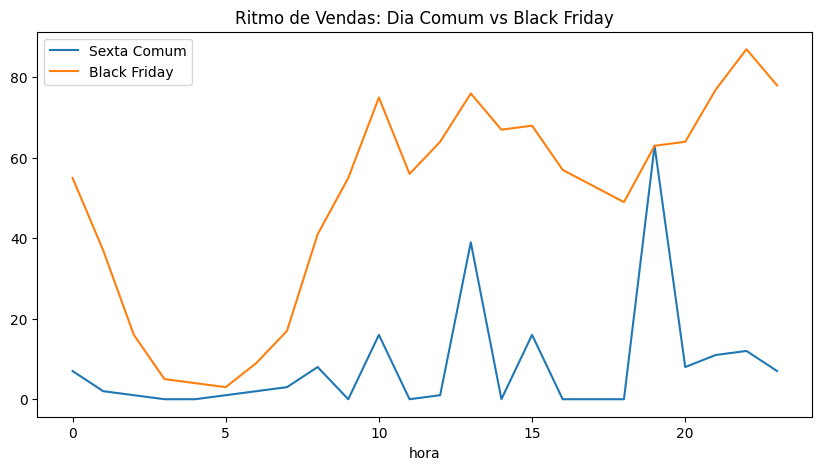

In [92]:
# Comparando o comportamento horário dos dois dias
bf_por_hora = vendas_bf['hora'].value_counts().sort_index()
comum_por_hora = vendas_comum['hora'].value_counts().sort_index()

# Criando um mini DataFrame para comparar lado a lado
comparativo_horas = pd.DataFrame({
    'Sexta Comum': comum_por_hora,
    'Black Friday': bf_por_hora
}).fillna(0)

comparativo_horas.plot(figsize=(10,5), title='Ritmo de Vendas: Dia Comum vs Black Friday')

Sempre que for trabalhar com Séries Temporais (horas, meses, dias) e usar o value_counts(), o sort_index() garante que o gráfico flua da esquerda para a direita corretamente.

Observa-se um comportamento de 'represamento' de demanda, onde o volume de pedidos às 00h da Black Friday é drasticamente superior a qualquer outro horário do dia comum. Para o negócio, isso indica a necessidade de escalabilidade agressiva do servidor e prontidão da equipe de prevenção a fraudes logo nas primeiras horas do evento."

Além do pico inicial na madrugada, há um ressurgimento expressivo de pedidos durante o horário comercial (12h-14h). Isso sugere que consumidores que não compraram na madrugada utilizam o intervalo de descanso para finalizar pedidos via mobile, validando estratégias de notificações Push e E-mail Marketing agendadas para o meio-dia.

O salto de 496.95% nas vendas demonstra que a base de clientes da Olist é altamente sensível a preço e sazonalidade. Contudo, a queda acentuada após as 22h sugere que o estoque dos principais 'heros' (produtos mais vendidos) pode ter se esgotado antes do fim do evento, revelando uma oportunidade de melhoria no planejamento de estoque (Demand Planning).



### 15.1. Resampling: Análise de Tendência de Longo Prazo
Para identificar se o negócio está crescendo mês a mês, utilizamos o método `.resample()`. Esta técnica permite alterar a frequência dos dados (ex: de dias para meses), aplicando funções de agregação como soma ou média. É a ferramenta ideal para suavizar ruídos diários e focar na tendência macro de crescimento da plataforma.

<Axes: title={'center': 'Evolução Total de Pedidos por Mês (2016-2018)'}, xlabel='order_purchase_timestamp'>

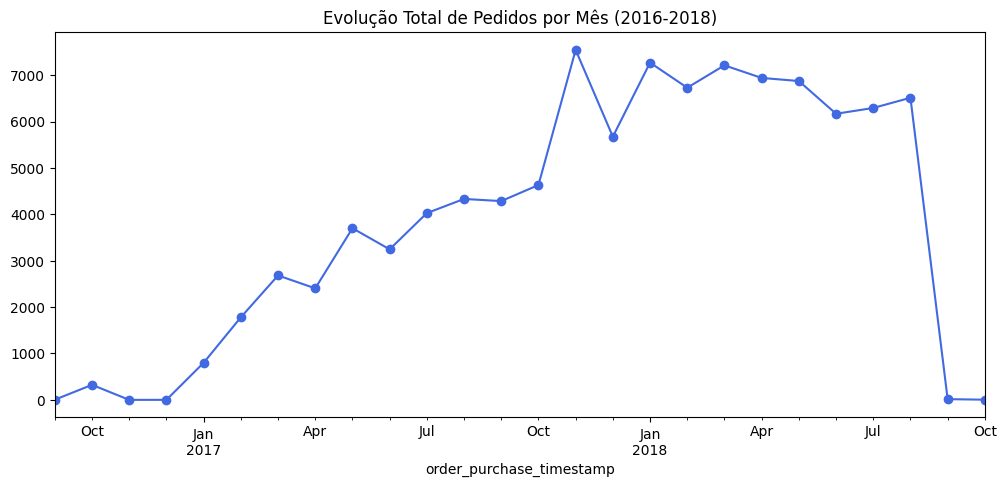

In [93]:
# 'ME' significa Month End (Final do Mês)
# .count() vai contar quantos pedidos (order_id) tivemos em cada mês
evolucao_mensal = df_tempo['order_id'].resample('ME').count()

# Plotando a evolução
evolucao_mensal.plot(
    figsize=(12, 5), 
    kind='line', 
    marker='o', 
    title='Evolução Total de Pedidos por Mês (2016-2018)',
    color='royalblue'
)

'W': Weekly (Semanal) - Ótimo para ver o ritmo de operação.

'D': Daily (Diário) - Para ver picos específicos (como feriados).

'QE': Quarter End (Trimestral) - O famoso "Q1, Q2, Q3" dos relatórios financeiros.

'YE': Year End (Anual) - Para ver o crescimento de um ano contra o outro.

#### Integração de Dados: Unindo Tempo e Valor (Price)
Para análises financeiras, realizamos o merge entre a tabela de pedidos (contendo o timestamp) e a tabela de itens (contendo o valor unitário). Este cruzamento permite converter uma série temporal de eventos em uma série temporal de faturamento, possibilitando o cálculo de métricas como Ticket Médio e Receita Mensal.

In [94]:
df_pedidos_data = pd.read_sql("SELECT order_id, order_purchase_timestamp FROM orders", conn)

query_itens = "SELECT order_id, price FROM order_items"
df_itens = pd.read_sql(query_itens, conn)

df_financeiro = pd.merge(df_pedidos_data, df_itens, on='order_id', how='inner')

df_financeiro['order_purchase_timestamp'] = pd.to_datetime(df_financeiro['order_purchase_timestamp'])

df_financeiro = df_financeiro.set_index('order_purchase_timestamp')


faturamento_mensal = df_financeiro['price'].resample('ME').sum()

print("Faturamento Mensal calculado!")
faturamento_mensal.tail()

Faturamento Mensal calculado!


order_purchase_timestamp
2018-05-31    996517.68
2018-06-30    865124.31
2018-07-31    895507.22
2018-08-31    854686.33
2018-09-30       145.00
Freq: ME, Name: price, dtype: float64

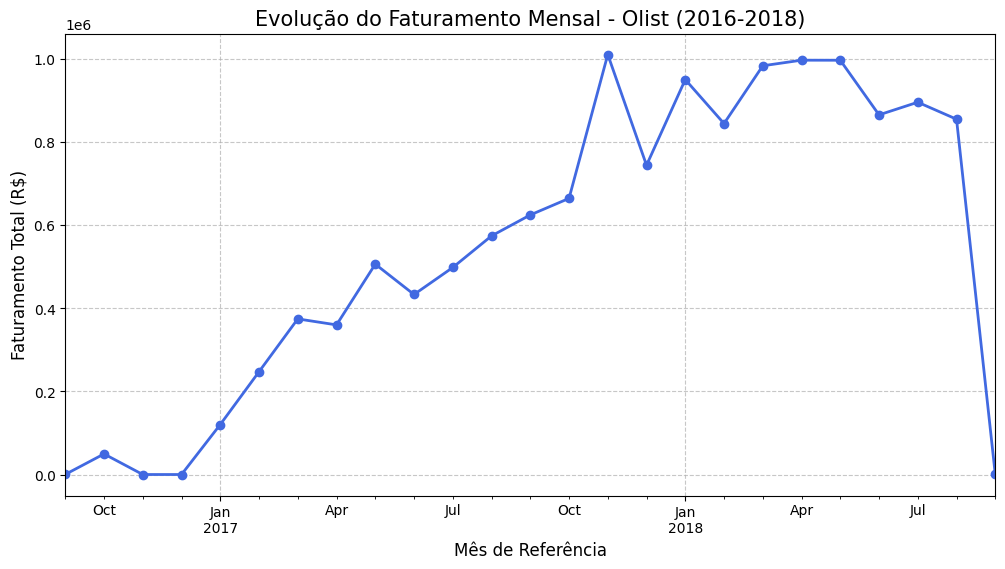

In [95]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(12, 6))
faturamento_mensal.plot(kind='line', marker='o', color='royalblue', linewidth=2)

# customizações
plt.title('Evolução do Faturamento Mensal - Olist (2016-2018)', fontsize=15)
plt.xlabel('Mês de Referência', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

#### Correlação entre Volume de Pedidos e Receita
Ao comparar os gráficos de Evolução de Pedidos e Evolução de Receita, observa-se uma correlação quase perfeita (proporcionalidade direta). 

**Insight de Negócio:**
Essa similaridade indica que o **Ticket Médio da plataforma permaneceu estável** durante o período de crescimento. O aumento da receita foi impulsionado primordialmente pela **aquisição de novos clientes** e volume de transações, e não pelo aumento do valor gasto por pedido. Para o planejamento estratégico, isso sugere que a Olist tem um perfil de consumo previsível, facilitando a projeção de faturamento com base em metas de volume de vendas.

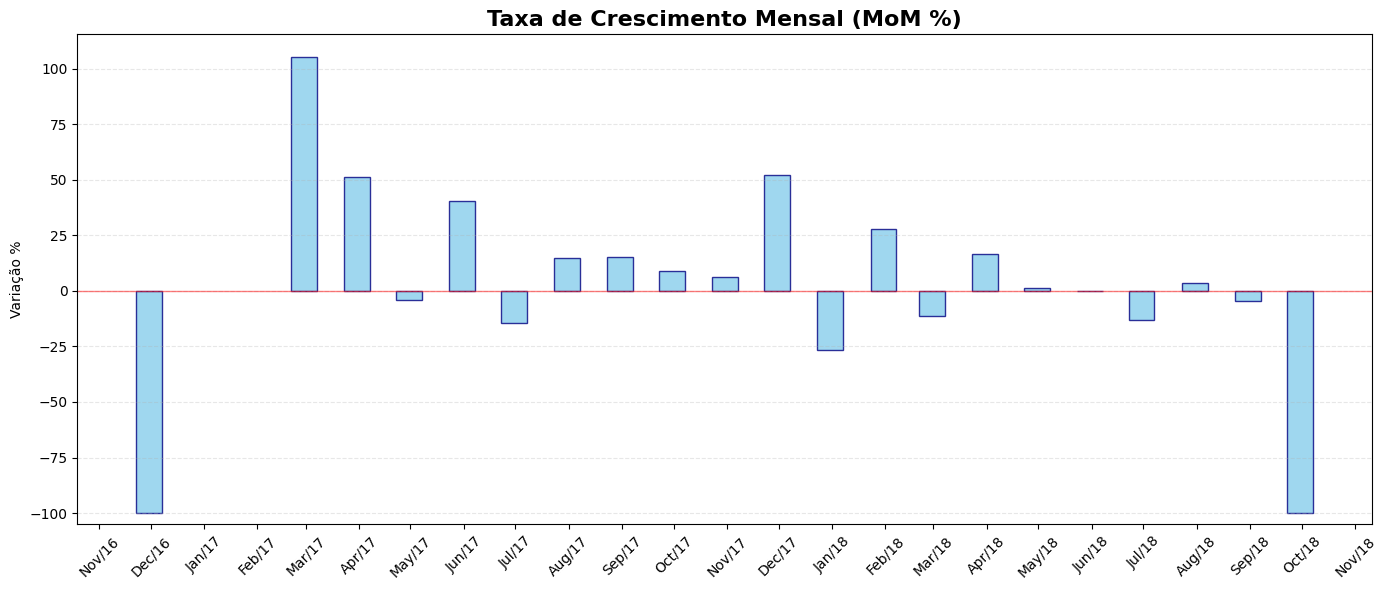

In [96]:
import numpy as np

# 1. remove NaNs e substitui Infinitos por NaN para removê-los também
dados_plot = crescimento_mensal.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Se o primeiro mês ainda estiver com um crescimento absurdo (ex: 5000%), 
# vamos filtrar para ver a partir de onde o negócio estabilizou
dados_plot = dados_plot[dados_plot < 500] # Filtra crescimentos irreais de início de operação

fig, ax = plt.subplots(figsize=(14, 6))

# 3. Criando o gráfico
bars = ax.bar(dados_plot.index, dados_plot.values, width=15, color='skyblue', edgecolor='navy', alpha=0.8)

# 4. Formatação de Datas (Eixo X)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
plt.xticks(rotation=45)

# 5. Definindo limites do Eixo Y de forma segura
if not dados_plot.empty:
    ymin = dados_plot.min() - 5
    ymax = dados_plot.max() + 10
    ax.set_ylim(ymin, ymax)

# 6. Linha de referência e títulos
ax.axhline(0, color='red', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('Taxa de Crescimento Mensal (MoM %)', fontsize=16, fontweight='bold')
ax.set_ylabel('Variação %')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Gráficos de Valor Acumulado (Faturamento/Pedidos) mostram o TAMANHO do negócio.

Gráficos de Crescimento (pct_change) mostram o RITMO do negócio.

In [97]:
# 1. Ordenando o índice cronologicamente
df_financeiro = df_financeiro.sort_index()

# filtro por data 
inicio_2017 = df_financeiro.loc['2017-01-01':'2017-02-28']

# 3. Agrupando os valores
vendas_inicio = inicio_2017['price'].resample('ME').agg(['sum', 'count'])
vendas_inicio.columns = ['Faturamento Total', 'Qtd Pedidos']

print("Janeiro e Fevereiro de 2017:")
print(vendas_inicio)

if vendas_inicio['Qtd Pedidos'].sum() > 0:
    print("\n✅ Existem vendas no período, o gráfico apenas as 'escondeu' devido à escala.")
else:
    print("\n⚠️ Realmente não há registros nestes meses no seu DataFrame atual.")

Janeiro e Fevereiro de 2017:
                          Faturamento Total  Qtd Pedidos
order_purchase_timestamp                                
2017-01-31                        120312.87          955
2017-02-28                        247303.02         1951

✅ Existem vendas no período, o gráfico apenas as 'escondeu' devido à escala.


#### Análise de Crescimento Mensal (Month-over-Month)

O gráfico acima apresenta a variação percentual do faturamento mês a mês, permitindo identificar a velocidade de expansão da plataforma e o impacto de eventos sazonais.

* **Impacto da Black Friday:** O pico de crescimento em **Novembro de 2017** confirma o sucesso das campanhas promocionais, sendo o ponto de maior aceleração do faturamento no período analisado.
* **Efeito "Ressaca" Pós-Evento:** A retração observada em **Dezembro de 2017** é um comportamento esperado no e-commerce brasileiro, onde o consumo é antecipado para a Black Friday, gerando uma queda técnica na comparação mensal subsequente.
* **Estabilização da Operação:** Após os meses iniciais de 2017 (fase de ramp-up), a empresa apresenta uma taxa de crescimento mais orgânica e menos volátil, indicando maturação do modelo de negócio.

##### 🛠️ Notas de Processamento (Data Cleaning):
Durante a geração desta visualização, foram aplicados os seguintes tratamentos:
1. **Tratamento de Indeterminações:** Remoção de valores `NaN` e `Inf` gerados pelo cálculo de variação sobre bases nulas ou inexistentes.
2. **Filtro de Outliers de Início:** Foram desconsiderados crescimentos superiores a 500% típicos do primeiro mês de operação, que distorciam a escala do eixo Y e impediam a leitura da performance real dos meses seguintes.
3. **Formatação Temporal:** Utilização do `mdates.DateFormatter` para garantir a legibilidade do eixo cronológico, evitando a sobreposição de rótulos.

## 16. Entrada e Saída de Dados (I/O)
A capacidade de integrar diferentes fontes de dados é vital. O Pandas oferece uma vasta biblioteca de funções `read_*` e `to_*` para interagir com diversos formatos:
* **CSV:** O formato mais comum (`read_csv`, `to_csv`).
* **Excel:** Muito usado em ambientes corporativos (`read_excel`).
* **JSON/XML:** Padrões para troca de dados via Web e APIs.
* **SQL:** Integração direta com bancos de dados relacionais, como o utilizado neste projeto.

In [98]:
# Exportando o resultado da análise para Excel (XLSX)
# O parâmetro index=True é importante porque a data está no índice!
faturamento_mensal.to_excel('relatorio_faturamento_olist.xlsx', index=True)

# Ou se preferir um CSV para outro sistema:
faturamento_mensal.to_csv('crescimento_olist.csv', sep=';', encoding='utf-8')

`chunksize`: Para ler arquivos de 10GB que não cabem na memória.

`usecols`: Para ler apenas as colunas que você precisa (economiza muita memória).

`parse_dates`: Já converte as colunas de data automaticamente durante a leitura, evitando aquele erro de "string vs datetime" que tivemos hoje.

## 17. Integração de Dicionários: Tradução de Categorias
Para tornar a análise acessível e internacionalizável, utilizamos a tabela de tradução de categorias. Este processo envolve a carga de um dicionário de dados via SQL e a sua integração com a base de produtos, permitindo que as visualizações finais utilizem nomenclaturas padronizadas.

In [99]:
# 1. Lendo a tabela de tradução e a de produtos
df_traducao = pd.read_sql("SELECT * FROM product_category_name_translation", conn)
df_produtos = pd.read_sql("SELECT product_id, product_category_name FROM products", conn)

# 2. Lendo os itens para saber qual produto foi vendido em cada pedido
df_itens_full = pd.read_sql("SELECT order_id, product_id, price FROM order_items", conn)

# 3. Cruzando tudo: Itens -> Produtos -> Tradução
df_consolidado = pd.merge(df_itens_full, df_produtos, on='product_id', how='left')
df_consolidado = pd.merge(df_consolidado, df_traducao, on='product_category_name', how='left')

# Visualizando o resultado
df_consolidado[['order_id', 'product_category_name', 'product_category_name_english', 'price']].head()

,order_id,product_category_name,product_category_name_english,price
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,cool_stuff,58.90
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,pet_shop,239.90
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao,furniture_decor,199.00
3,00024acbcdf0a6daa1e931b038114c75,perfumaria,perfumery,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim,garden_tools,199.90


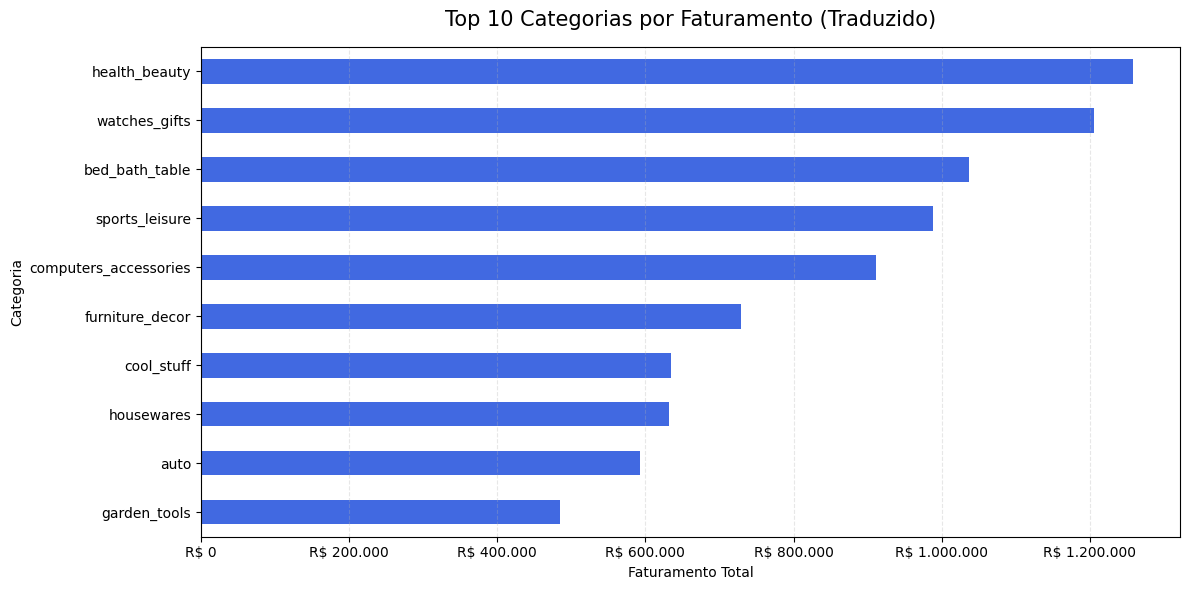

In [100]:
import matplotlib.ticker as ticker

# 1. Agrupamento
top_categorias = df_consolidado.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

# 2. Criando a figura e o eixo )
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Plotando usando o 'ax' que criamos
top_categorias.plot(kind='barh', color='royalblue', ax=ax)

# 4. Função de formatação
def format_reais(x, _):
    return f'R$ {x:,.0f}'.replace(',', '.')

# 5. Aplicando o formatador no eixo X do objeto 'ax'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_reais))

# 6. Detalhes finais
plt.title('Top 10 Categorias por Faturamento (Traduzido)', fontsize=15, pad=15)
plt.xlabel('Faturamento Total')
plt.ylabel('Categoria')
ax.invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()